In [31]:
import kagglehub

In [32]:
print("Kaggle authenticated:", kagglehub.auth)

Kaggle authenticated: <module 'kagglehub.auth' from 'C:\\Users\\shaki\\PycharmProjects\\JupyterProject\\.venv\\Lib\\site-packages\\kagglehub\\auth.py'>


download dataset from kaggle, and it is stored here: C:\Users\shaki\.cache\kagglehub

In [33]:
path = kagglehub.dataset_download("rohankayan/years-of-experience-and-salary-dataset")

In [34]:
import pandas as pd

In [35]:
df = pd.read_csv('salary_data.csv')

In [36]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [37]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [38]:
df.shape

(30, 2)

In [39]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'salary')

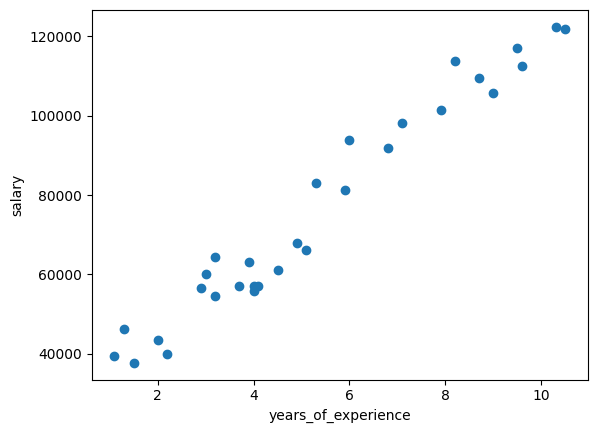

In [40]:
plt.scatter(df['YearsExperience'], df['Salary'])
plt.xlabel('years_of_experience')
plt.ylabel('salary')

when we from and import it means that we can directly use "train_test_split" otherwise we have sklearn......... or the as plt keywords.

In [41]:
from sklearn.model_selection import train_test_split

random state is basically seed for generation (using 42 is preferred)

In [42]:
x_train, x_test, y_train, y_test = train_test_split(df['YearsExperience'], df['Salary'], test_size=0.2, random_state=42)

In [43]:
x_train.shape

(24,)

In [44]:
y_train.shape

(24,)

In [45]:
print(df.values)

[[1.10000e+00 3.93430e+04]
 [1.30000e+00 4.62050e+04]
 [1.50000e+00 3.77310e+04]
 [2.00000e+00 4.35250e+04]
 [2.20000e+00 3.98910e+04]
 [2.90000e+00 5.66420e+04]
 [3.00000e+00 6.01500e+04]
 [3.20000e+00 5.44450e+04]
 [3.20000e+00 6.44450e+04]
 [3.70000e+00 5.71890e+04]
 [3.90000e+00 6.32180e+04]
 [4.00000e+00 5.57940e+04]
 [4.00000e+00 5.69570e+04]
 [4.10000e+00 5.70810e+04]
 [4.50000e+00 6.11110e+04]
 [4.90000e+00 6.79380e+04]
 [5.10000e+00 6.60290e+04]
 [5.30000e+00 8.30880e+04]
 [5.90000e+00 8.13630e+04]
 [6.00000e+00 9.39400e+04]
 [6.80000e+00 9.17380e+04]
 [7.10000e+00 9.82730e+04]
 [7.90000e+00 1.01302e+05]
 [8.20000e+00 1.13812e+05]
 [8.70000e+00 1.09431e+05]
 [9.00000e+00 1.05582e+05]
 [9.50000e+00 1.16969e+05]
 [9.60000e+00 1.12635e+05]
 [1.03000e+01 1.22391e+05]
 [1.05000e+01 1.21872e+05]]


In [46]:
print(df['YearsExperience'].values)

[ 1.1  1.3  1.5  2.   2.2  2.9  3.   3.2  3.2  3.7  3.9  4.   4.   4.1
  4.5  4.9  5.1  5.3  5.9  6.   6.8  7.1  7.9  8.2  8.7  9.   9.5  9.6
 10.3 10.5]


In [47]:
import sklearn.linear_model

In [48]:
model = sklearn.linear_model.LinearRegression()

the syntax below is like this: it's from "Features" predict "Target"
X capital ? fn(X) = y
also (-1, 1) (rows, columns) -1 = calculate columns automatically

In [49]:
model.fit(df['YearsExperience'].values.reshape(-1, 1), df['Salary'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


values = convert it to numpy array

In [50]:
y_pred = model.predict(x_test.values.reshape(-1, 1))

Text(0, 0.5, 'salary')

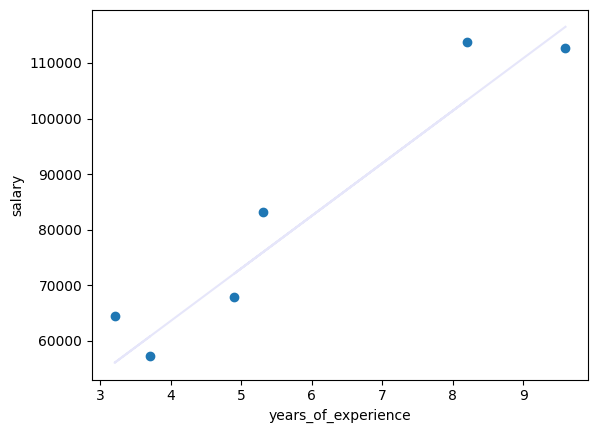

In [51]:
plt.scatter(x_test, y_test)
plt.plot(x_test, y_pred, color='lavender')
plt.xlabel('years_of_experience')
plt.ylabel('salary')

In [52]:
import sklearn.metrics as metrics

In [53]:
metrics.r2_score(y_test, y_pred)

0.9090578530656058

In [54]:
metrics.mean_absolute_error(y_test, y_pred)

6292.99058036377

In [55]:
first_experience = x_test.values[0]

In [56]:
predicted_salary = model.predict(first_experience.reshape(-1, 1))[0]

In [57]:
actual_salary = y_test.values[0]

In [58]:
print(first_experience)
print("predicted_salary: ", predicted_salary, "actual salary", actual_salary)

9.6
predicted_salary:  116511.83848463741 actual salary 112635.0
